📥 Loading Data...
✅ Total Data Loaded: 5605 sentences

✂️ Splitting Data (80% Train, 20% Test)...
Training Set: 4484 samples
Testing Set:  1121 samples

⚙️ Engineering Features...
Final Input Shape: (4484, 5572)

⏱️ Training Model...
✅ Training Complete in 1.6434 seconds

⏱️ Measuring Inference Speed...
------------------------------
LOGISTIC REGRESSION RESULTS (80/20 Split):
Accuracy:        85.01%
F1-Score:        0.85
Inference Speed: 271813 sent/sec
------------------------------

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Joy       0.88      0.87      0.87       306
     Sadness       0.84      0.82      0.83       222
     Sarcasm       0.87      0.78      0.82       186
       Anger       0.84      0.85      0.85       201
     Neutral       0.82      0.91      0.86       206

    accuracy                           0.85      1121
   macro avg       0.85      0.85      0.85      1121
weighted avg       0.85      0.85      0.85      1121


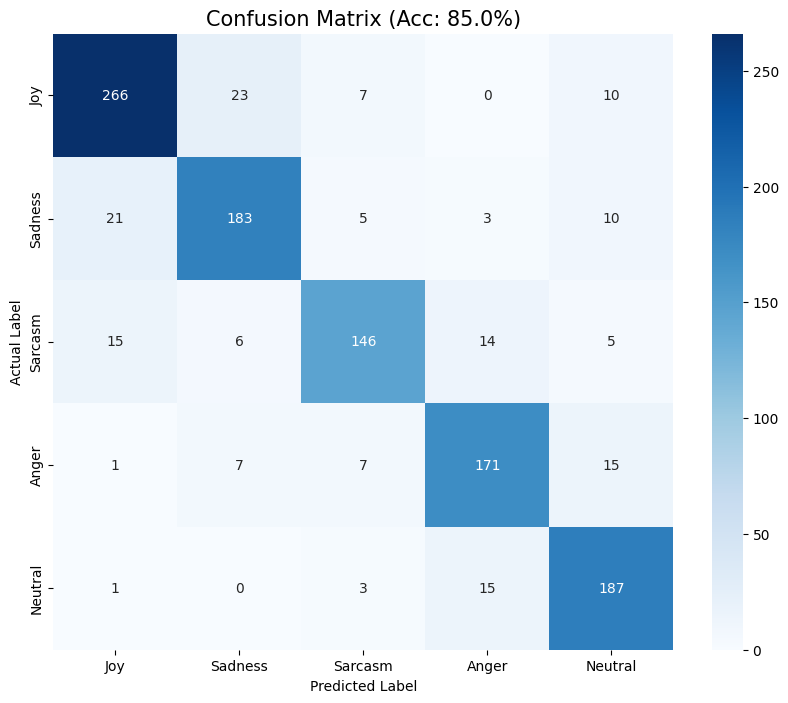

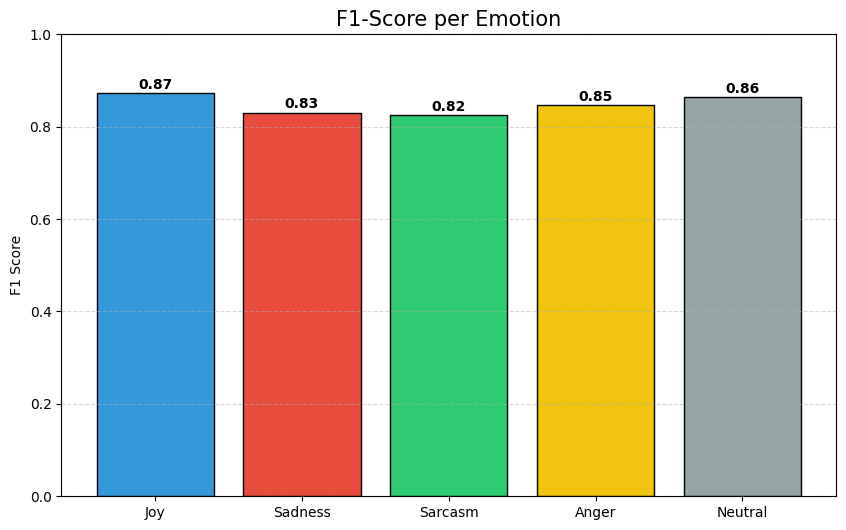

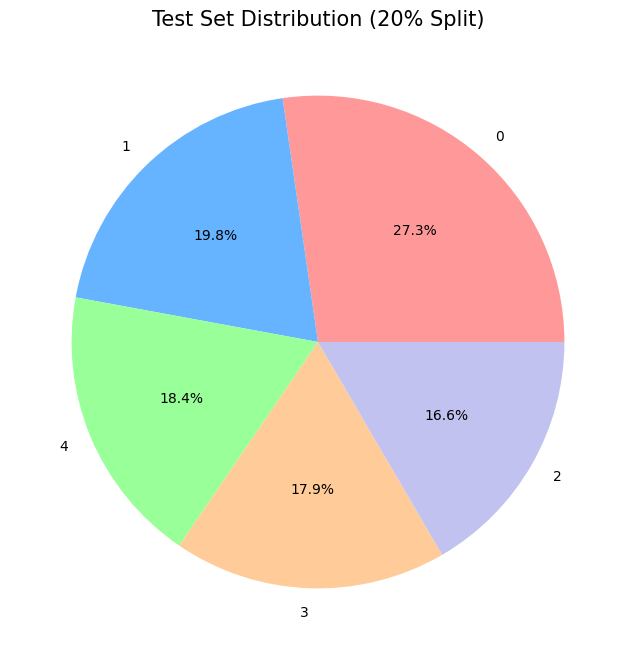


🎉 Pipeline Complete. Files saved in Output.


In [1]:
import pandas as pd
import numpy as np
import os
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from scipy.sparse import hstack

# ==========================================
# 1. CONFIGURATION & DICTIONARIES
# ==========================================
# Roman Urdu Stop Words
roman_urdu_stop_words = [
    "hai", "hain", "han", "ho", "hun", "h", "tha", "thi", "thay", "the",
    "ga", "gi", "ge", "raha", "rahi", "rahay", "rha", "rhi",
    "ka", "ki", "ke", "k", "ko", "ne", "se", "sy", "par", "pe", "pr", "per",
    "mein", "me", "mn", "men", "aur", "or", "ao", "bhi", "bh", "to", "toh",
    "liye", "lye", "main", "men", "mjhy", "mujhe", "hum", "hamein",
    "tum", "tu", "ap", "aap", "wo", "woh", "us", "iss", "is", "jo", "jis",
    "ye", "yeh", "apna", "apni", "apne", "kar", "kr", "karna", "krna", "kya",
    "hona", "ho", "hue", "huway", "gaya", "gye", "gai", "gay", "wala", "walay", "wali",
    "sakta", "sakti", "sakte", "wese", "bus", "bas"
]
final_stop_words = list(ENGLISH_STOP_WORDS) + roman_urdu_stop_words

# Emotion Dictionary with Emojis
emotion_dict = {
    "joy": ["happy", "fun", "love", "best", "thrilled", "excited", "mubarak", "zabardast", "😊", "😁", "😄", "🤩", "🥳", "😎", "💖", "✨"],
    "sadness": ["sad", "cry", "miss", "bad", "sorrow", "afsos", "dukh", "ron", "😢", "😞", "😔", "😿", "💔", "🥺"],
    "sarcasm": ["yeah", "right", "wow", "totally", "favorite", "kamal", "shabash", "waah", "as if", "bht achay"],
    "anger": ["hate", "angry", "stupid", "worst", "bakwas", "lanat", "ghatiya", "fraud", "jhoot", "mad", "😡", "😠", "🤬", "👿"],
    "neutral": ["theek", "sahi", "ok", "normal", "acha", "hmm", "bas", "😐", "😶", "🤔", "😑"]
}

# ==========================================
# 2. DATA LOADING
# ==========================================
def load_data(file_path, label_code):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        cleaned_lines = [line.strip() for line in lines if line.strip()]
        df = pd.DataFrame({'text': cleaned_lines})
        df['label'] = label_code
        return df
    except Exception as e:
        # Fallback for encoding issues
        try:
            with open(file_path, 'r', encoding='latin-1') as f:
                lines = f.readlines()
            cleaned_lines = [line.strip() for line in lines if line.strip()]
            df = pd.DataFrame({'text': cleaned_lines})
            df['label'] = label_code
            return df
        except:
            print(f"❌ Error loading {file_path}")
            return pd.DataFrame()

print("📥 Loading Data...")
# Define paths (Ensure these match your Kaggle Input exactly)
base_path = "/kaggle/input/normalised-training-data/"
df_joy = load_data(base_path + "normalized_td_joy.txt", 0)
df_sad = load_data(base_path + "normalized_td_sadness.txt", 1)
df_sarc = load_data(base_path + "normalized_td_sarcasm.txt", 2)
df_ang = load_data(base_path + "training_data_anger.txt", 3)
df_neu = load_data(base_path + "training_data_neutral.txt", 4)

# Combine into Master Dataset
df_total = pd.concat([df_joy, df_sad, df_sarc, df_ang, df_neu], axis=0)
df_total = df_total.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Total Data Loaded: {len(df_total)} sentences")

# ==========================================
# 3. THE 80/20 SPLIT
# ==========================================
print("\n✂️ Splitting Data (80% Train, 20% Test)...")
# X contains the raw text, y contains the labels
# stratify=y ensures the % of emotions is balanced in both sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_total['text'], 
    df_total['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_total['label']
)

print(f"Training Set: {len(X_train_raw)} samples")
print(f"Testing Set:  {len(X_test_raw)} samples")

# ==========================================
# 4. FEATURE ENGINEERING (TF-IDF + MANUAL)
# ==========================================
print("\n⚙️ Engineering Features...")

# A. TF-IDF
# IMPORTANT: Fit only on Train, Transform on Test to avoid leakage
tfidf = TfidfVectorizer(max_features=None, min_df=2, stop_words=final_stop_words)
X_train_tfidf = tfidf.fit_transform(X_train_raw.astype(str))
X_test_tfidf = tfidf.transform(X_test_raw.astype(str))

# B. Manual Dictionary Counts
def get_manual_features(text_series):
    features = []
    for text in text_series:
        words = str(text).lower().split()
        counts = [
            sum(1 for w in emotion_dict['joy'] if w in words),
            sum(1 for w in emotion_dict['sadness'] if w in words),
            sum(1 for w in emotion_dict['sarcasm'] if w in words),
            sum(1 for w in emotion_dict['anger'] if w in words) # Ensure order matches training
        ]
        features.append(counts)
    return np.array(features)

X_train_manual = get_manual_features(X_train_raw)
X_test_manual = get_manual_features(X_test_raw)

# C. Stack Features
X_train_final = hstack([X_train_tfidf, X_train_manual])
X_test_final = hstack([X_test_tfidf, X_test_manual])

print(f"Final Input Shape: {X_train_final.shape}")

# ==========================================
# 5. TRAINING & TIMING
# ==========================================
print("\n⏱️ Training Model...")
start_train = time.time()

model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train_final, y_train)

end_train = time.time()
training_time = end_train - start_train
print(f"✅ Training Complete in {training_time:.4f} seconds")

# ==========================================
# 6. EVALUATION & SPEED TEST
# ==========================================
print("\n⏱️ Measuring Inference Speed...")
start_pred = time.time()

y_pred = model.predict(X_test_final)

end_pred = time.time()
prediction_time = end_pred - start_pred
sentences_per_sec = len(y_test) / prediction_time

# Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
label_names = ["Joy", "Sadness", "Sarcasm", "Anger", "Neutral"]

print("-" * 30)
print(f"LOGISTIC REGRESSION RESULTS (80/20 Split):")
print(f"Accuracy:        {acc*100:.2f}%")
print(f"F1-Score:        {f1:.2f}")
print(f"Inference Speed: {sentences_per_sec:.0f} sent/sec")
print("-" * 30)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=label_names))

# ==========================================
# 7. VISUALIZATIONS & SAVING
# ==========================================

# A. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix (Acc: {acc*100:.1f}%)', fontsize=15)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('/kaggle/working/lr_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# B. F1 Score Bar Chart
report = classification_report(y_test, y_pred, target_names=label_names, output_dict=True)
f1_scores = [report[label]['f1-score'] for label in label_names]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#95a5a6'] # Blue, Red, Green, Yellow, Gray

plt.figure(figsize=(10, 6))
bars = plt.bar(label_names, f1_scores, color=colors, edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', fontweight='bold')
plt.title('F1-Score per Emotion', fontsize=15)
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('/kaggle/working/lr_f1_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# C. Dataset Pie Chart (Test Data Distribution)
plt.figure(figsize=(8, 8))
y_test.value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0'])
plt.title('Test Set Distribution (20% Split)', fontsize=15)
plt.ylabel('')
plt.savefig('/kaggle/working/lr_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 8. SAVE MODEL FILES
# ==========================================
joblib.dump(model, "/kaggle/working/roman_urdu_model.pkl")
joblib.dump(tfidf, "/kaggle/working/tfidf_vectorizer.pkl")
print("\n🎉 Pipeline Complete. Files saved in Output.")